In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

2026-04-25 21:10:34.906838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777151435.131450      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777151435.197710      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777151435.739107      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777151435.739150      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777151435.739153      55 computation_placer.cc:177] computation placer alr

In [2]:
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_data = keras.preprocessing.sequence.pad_sequences(train_data, maxlen=200)
test_data = keras.preprocessing.sequence.pad_sequences(test_data, maxlen=200)


In [4]:
L2 = tf.keras.regularizers.l2(0.001)
model = keras.Sequential([
    keras.layers.Embedding(10000,128),
    keras.layers.Bidirectional(tf.keras.layers.LSTM(64, kernel_regularizer=L2)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(24,activation='relu', kernel_regularizer=L2),
    keras.layers.Dense(1,activation='sigmoid')
])



2026-04-25 21:11:05.501439: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
opti = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opti,
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(train_data,train_labels,callbacks=[early_stop] ,epochs=10,batch_size=32, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 88ms/step - accuracy: 0.6805 - loss: 0.6712 - val_accuracy: 0.8516 - val_loss: 0.3730
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.8523 - loss: 0.3695 - val_accuracy: 0.8728 - val_loss: 0.3420
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9181 - loss: 0.2377 - val_accuracy: 0.8144 - val_loss: 0.4125
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9333 - loss: 0.2009 - val_accuracy: 0.8646 - val_loss: 0.3736


In [7]:
loss, accuracy = model.evaluate(test_data, test_labels)
print(f'accuracy: {accuracy * 100:.2f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8595 - loss: 0.3551
accuracy: 86.35


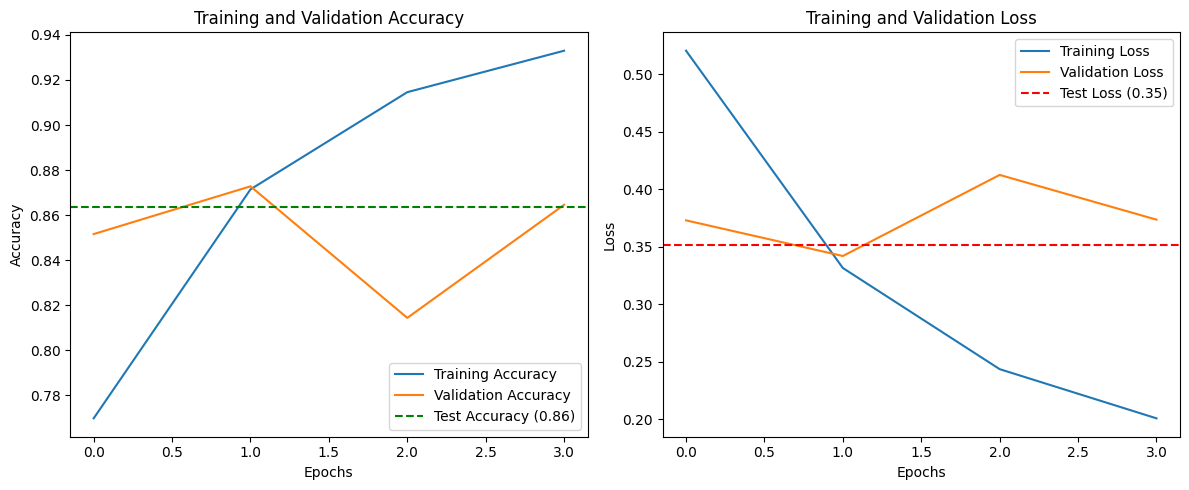

In [8]:
acc = history.history['accuracy']
lossT = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axhline(y=accuracy, color='g', linestyle='--', label=f'Test Accuracy ({accuracy:.2f})')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, lossT, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axhline(y=loss, color='r', linestyle='--', label=f'Test Loss ({loss:.2f})')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()